# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [2]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [3]:
bandit0 = BanditProblem(0)

In [4]:
bandit0.get_num_arms()

3

In [ ]:
bandit0.get_reward(arm=0)

1.8255111545554434

Arm 0: mean=0.815, std=0.784
Arm 1: mean=0.573, std=0.634
Arm 2: mean=0.926, std=0.848


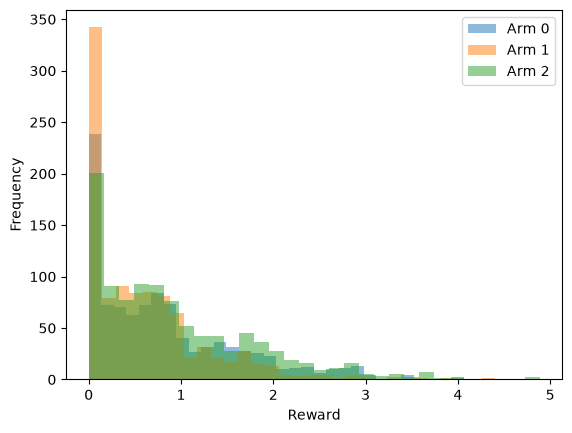

In [9]:
import matplotlib.pyplot as plt

bandit0 = BanditProblem(0)

num_samples = 1000

rewards = []

for arm in range(bandit0.get_num_arms()):
    arm_rewards = [
        bandit0.get_reward(arm)
        for _ in range(num_samples)
    ]
    
    rewards.append(arm_rewards)
    
    print(
        f"Arm {arm}: "
        f"mean={np.mean(arm_rewards):.3f}, "
        f"std={np.std(arm_rewards):.3f}"
    )

for arm in range(bandit0.get_num_arms()):
    plt.hist(
        rewards[arm],
        bins=30,
        alpha=0.5,
        label=f"Arm {arm}"
    )

plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [10]:
algo_choice = """Because the arms have continuous, overlapping reward distributions, UCB is most suitable because it handles numeric rewards while balancing exploration and exploitation based on uncertainty.
"""

with open("algorithm-choice.txt", "w") as f:
    f.write(algo_choice)

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [12]:
# Create the bandit 
bandit = BanditProblem(2026)

K = bandit.get_num_arms()
T = 1000

In [13]:
# Decide what UCB needs to keep track of
counts = np.zeros(K)
estimated_rewards = np.zeros(K)

In [ ]:
# Save which arm was selected on each of the 1,000 rounds
actions = []
rewards = []

# Pull every arm once
for arm in range(K):
    reward = bandit.get_reward(arm)

    counts[arm] += 1
    estimated_rewards[arm] = reward

    actions.append(arm)
    rewards.append(reward)

for t in range(K, T):
    # Implement the UCB calculation
    ucb_values = estimated_rewards + np.sqrt(
        2 * np.log(t + 1) / counts
    )

    # Select the arm with the largest UCB
    arm = np.argmax(ucb_values)

    # Get the reward
    reward = bandit.get_reward(arm)

    # Record it 
    actions.append(arm)
    rewards.append(reward)

    # Update count 
    counts[arm] += 1

    # Update estimated mean reward
    estimated_rewards[arm] += (
        reward - estimated_rewards[arm]
    ) / counts[arm]


In [ ]:
# Verify 1,000 decisions made
len(actions)
len(rewards)

1000

In [24]:
# Look at how frequently UCB selected each arm
print("Arm counts:", counts)
print("Estimated rewards:", estimated_rewards)

Arm counts: [982.  17.  14.]
Estimated rewards: [1.21261374 0.40779753 0.28299412]


In [ ]:
# Create a DataFrame with results from UCB loop
import pandas as pd

history = pd.DataFrame({
    "action": actions,
    "reward": rewards
})

history.head()

(1000, 2)

Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [28]:
# Write history to tsv
history.to_csv("history.tsv", sep="\t", index=False)

Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [30]:
# Group results from history by action
action_stats = (
    history.groupby("action")["reward"]
    .agg(["min", "mean", "max"])
    .reset_index()
)

# Rename the columns 
action_stats = action_stats.rename(columns={
    "min": "min_reward",
    "mean": "mean_reward",
    "max": "max_reward"
})

action_stats

,action,min_reward,mean_reward,max_reward
0,0,0.0,1.212610,6.564312
1,1,0.0,0.241945,0.946820
2,2,0.0,0.223087,0.907359


In [31]:
# Save to tsv
action_stats.to_csv(
    "actions.tsv",
    sep="\t",
    index=False
)

Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [41]:
# Unfirom Regret
# Define the estimated best reward
best_mean_reward = action_stats["mean_reward"].max()

# Optimal reward over 1000 actions
optimal_reward = best_mean_reward * 1000

# Uniform strategy: expected reward per action is simply the average of your etimated arm means
uniform_mean = action_stats["mean_reward"].mean()

# Estimated uniform reward over 1000 actions 
uniform_reward = uniform_mean * 1000

# Regret
uniform_regret = optimal_reward - uniform_reward
uniform_regret

np.float64(653.3960069062776)

In [39]:
# Just-i Regret 

just_regrets = []

for i in range(K):
    arm_mean = action_stats.loc[
        action_stats["action"] == i,
        "mean_reward"
    ].iloc[0]

    regret = 1000 * (
        best_mean_reward - arm_mean
    )

    just_regrets.append(regret)

just_regrets

[np.float64(0.0), np.float64(970.6650799449266), np.float64(989.522940773906)]

In [40]:
# Calculate regret for actual UCB startegy
mean_lookup = action_stats.set_index("action")["mean_reward"]

actual_expected_reward = history["action"].map(
    mean_lookup
).sum()

actual_regret = optimal_reward - actual_expected_reward
actual_regret

np.float64(22.513875447023338)

Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [43]:
# Write to tsv
strategies = pd.DataFrame({
    "strategy": (
        ["uniform"]
        + [f"just-{i}" for i in range(K)]
        + ["actual"]
    ),
    "regret": (
        [uniform_regret]
        + just_regrets
        + [actual_regret]
    )
})

strategies.to_csv(
    "strategies.tsv",
    sep="\t",
    index=False
)

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

In [44]:
acknowledgments = """
I used the DX 704 Week 3 example code as a reference for the multi-armed bandit implementation and visualization.

Additional references:
Analytics Vidhya - Multi-Armed Bandit Problem & Its Implementation in Python:
https://www.analyticsvidhya.com/blog/2018/09/reinforcement-multi-armed-bandit-scratch-python/

GenRL - Upper Confidence Bound (UCB) Tutorial:
https://genrl.readthedocs.io/en/stable/usage/tutorials/bandit/ucb.html

"""

with open("acknowledgments.txt", "w") as f:
    f.write(acknowledgments)

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.